In [2]:
!python --version


Python 3.11.13


In [4]:
!pip install tensorflow

In [5]:
import tensorflow as tf
print(tf.__version__)


2.18.0


Saving sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv to sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022 (2).csv
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8198 - loss: 0.4468 - val_accuracy: 0.9603 - val_loss: 0.1675
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9401 - loss: 0.2365 - val_accuracy: 0.9603 - val_loss: 0.1669
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9401 - loss: 0.2325 - val_accuracy: 0.9603 - val_loss: 0.1662
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9401 - loss: 0.2317 - val_accuracy: 0.9603 - val_loss: 0.1684
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9401 - loss: 0.2367 - val_accuracy: 0.9603 - val_loss: 0.1684
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9401 - loss: 0.2283 - val_accuracy: 0.9603 - val_loss: 0.1669
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
17/17 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [23:00:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipython-input-17-3078582277.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat, feature_names=[f"LSTM_{i}" for i in range(X_train_flat.shape[1])])


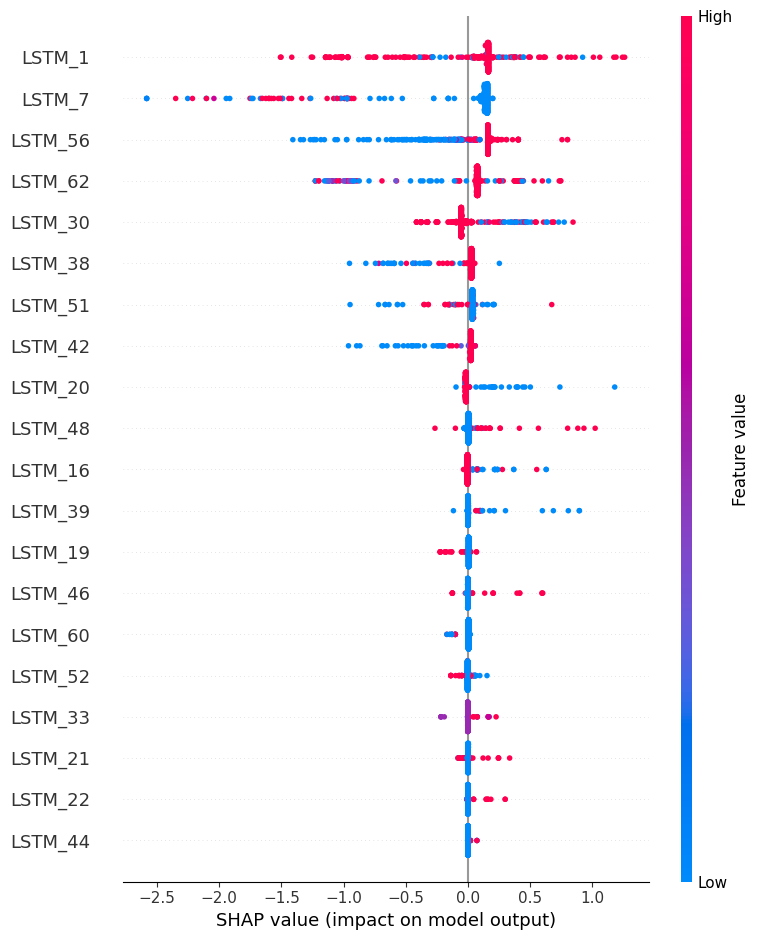

In [17]:
# 1️⃣ Imports
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import files
import matplotlib.pyplot as plt

# 2️⃣ Upload and Read Dataset
uploaded = files.upload()
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 3️⃣ Feature Selection & Sequence Preparation
df = df.sort_values(['Country', 'Year'])
features = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

sequence_length = 5
X_sequences, y_labels = [], []

for country in df['Country'].unique():
    country_df = df[df['Country'] == country]
    for i in range(len(country_df) - sequence_length):
        seq_X = country_df.iloc[i:i+sequence_length][features].values
        target_y = country_df.iloc[i+sequence_length]['Default']
        X_sequences.append(seq_X)
        y_labels.append(target_y)

X_sequences = np.array(X_sequences)
y_labels = np.array(y_labels)

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 5️⃣ LSTM Model - Functional API
input_layer = Input(shape=(sequence_length, len(features)))
x = LSTM(64, return_sequences=False, name='lstm_layer')(input_layer)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train LSTM Model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 7️⃣ Extract LSTM Embeddings
embedding_model = Model(inputs=model.input, outputs=model.get_layer('lstm_layer').output)
X_train_embed = embedding_model.predict(X_train)
X_test_embed = embedding_model.predict(X_test)

X_train_flat = X_train_embed.reshape((X_train_embed.shape[0], -1))
X_test_flat = X_test_embed.reshape((X_test_embed.shape[0], -1))

# 8️⃣ Train XGBoost on Embeddings
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=100,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)
xgb_model.fit(X_train_flat, y_train)

# 9️⃣ Evaluate Model
y_pred = xgb_model.predict(X_test_flat)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n✅ Hybrid model Accuracy: {acc:.3f}")
print(f"✅ Hybrid model F1 Score: {f1:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 🔟 SHAP Interpretation
explainer = shap.Explainer(xgb_model, X_train_flat)
shap_values = explainer(X_test_flat)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test_flat, feature_names=[f"LSTM_{i}" for i in range(X_train_flat.shape[1])])

